In [1]:
!pip install -q tensorflow-datasets
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
ds, info = tfds.load("beans", as_supervised=True, with_info=True)
train_ds = ds["train"]
val_ds   = ds["validation"]
test_ds  = ds["test"]

print(info)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.ETVDNP_0.1.0/beans-train.tfrecord*...:   0%|          | 0…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.ETVDNP_0.1.0/beans-validation.tfrecord*...:   0%|        …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.ETVDNP_0.1.0/beans-test.tfrecord*...:   0%|          | 0/…

Dataset beans downloaded and prepared to /root/tensorflow_datasets/beans/0.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='beans',
    full_name='beans/0.1.0',
    description="""
    Beans is a dataset of images of beans taken in the field using smartphone
    cameras. It consists of 3 classes: 2 disease classes and the healthy class.
    Diseases depicted include Angular Leaf Spot and Bean Rust. Data was annotated by
    experts from the National Crops Resources Research Institute (NaCRRI) in Uganda
    and collected by the Makerere AI research lab.
    """,
    homepage='https://github.com/AI-Lab-Makerere/ibean/',
    data_dir='/root/tensorflow_datasets/beans/0.1.0',
    file_format=tfrecord,
    download_size=171.69 MiB,
    dataset_size=171.63 MiB,
    features=FeaturesDict({
        'image': Image(shape=(500, 500, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    di

In [3]:
IMG_SIZE = (224, 224)

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


In [4]:
X_list, y_list = [], []

for batch_images, batch_labels in train_ds.map(preprocess).batch(32):
    X_list.append(batch_images.numpy())
    y_list.append(batch_labels.numpy())

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print(X.shape, y.shape)


(1034, 224, 224, 3) (1034,)


In [5]:
def make_pairs(images, labels):
    pairs = []
    pair_labels = []

    num_classes = len(np.unique(labels))
    class_idx = [np.where(labels == i)[0] for i in range(num_classes)]

    for i in range(len(images)):
        x1 = images[i]
        label = labels[i]

        # positive pair
        pos = np.random.choice(class_idx[label])
        pairs.append([x1, images[pos]])
        pair_labels.append(1)

        # negative pair
        neg_label = np.random.choice([l for l in range(num_classes) if l != label])
        neg = np.random.choice(class_idx[neg_label])
        pairs.append([x1, images[neg]])
        pair_labels.append(0)

    return np.array(pairs), np.array(pair_labels)

pairs, pair_labels = make_pairs(X, y)
A = pairs[:,0]
B = pairs[:,1]
Y = pair_labels.astype("float32")

print(A.shape, B.shape, Y.shape)


(2068, 224, 224, 3) (2068, 224, 224, 3) (2068,)


In [6]:
def build_embedding():
    base = keras.applications.MobileNetV2(
        include_top=False, input_shape=(*IMG_SIZE,3), weights="imagenet"
    )
    base.trainable = False

    inp = keras.Input((*IMG_SIZE,3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128)(x)
    x = layers.Lambda(lambda t: tf.nn.l2_normalize(t, axis=1))(x)
    return keras.Model(inp, x)

embedding_model = build_embedding()

inp_a = keras.Input((*IMG_SIZE,3))
inp_b = keras.Input((*IMG_SIZE,3))

emb_a = embedding_model(inp_a)
emb_b = embedding_model(inp_b)


output = layers.Lambda(lambda t: tf.stack(t, axis=1))([emb_a, emb_b])

siamese = keras.Model([inp_a, inp_b], output)
siamese.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 128)       │  2,421,952 │ input_layer_2[0]… │
│ (Functional)        │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 2, 128)    │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 163,968 (640.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
def contrastive_loss(y_true, y_pred, margin=1.0):
    emb_a = y_pred[:, 0]
    emb_b = y_pred[:, 1]

    d = tf.reduce_sum(tf.square(emb_a - emb_b), axis=1)
    return tf.reduce_mean(y_true * d + (1 - y_true) * tf.maximum(margin - d, 0))


In [8]:
siamese.compile(optimizer=keras.optimizers.Adam(1e-4),
                loss=contrastive_loss)

history = siamese.fit([A, B], Y,
                      batch_size=32,
                      epochs=10,
                      validation_split=0.1)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 58s 602ms/step - loss: 0.4600 - val_loss: 0.4162
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.3936 - val_loss: 0.3734
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.3531 - val_loss: 0.3456
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.3257 - val_loss: 0.3251
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.3060 - val_loss: 0.3107
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.2908 - val_loss: 0.2982
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.2770 - val_loss: 0.2883
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.2650 - val_loss: 0.2808
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.2554 - val_loss: 0.2746
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.2466 - val_loss: 0.2693


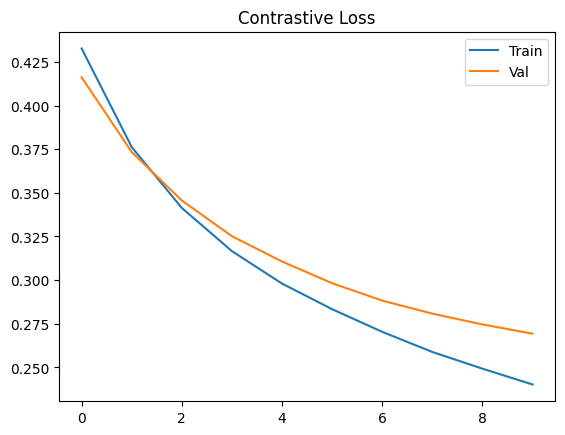

In [9]:
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.legend()
plt.title("Contrastive Loss")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


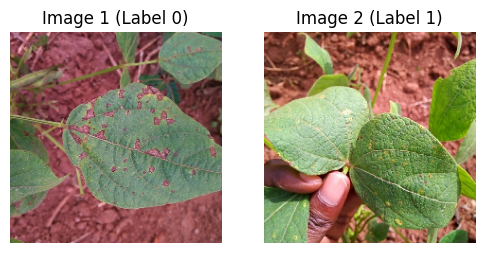

Distance: 1.6343037
DIFFERENT PART TYPE (Not match)


In [16]:
import random
import matplotlib.pyplot as plt

# Convert entire test dataset to arrays ONCE
test_X_list, test_y_list = [], []

for batch_images, batch_labels in test_ds.map(preprocess).batch(32):
    test_X_list.append(batch_images.numpy())
    test_y_list.append(batch_labels.numpy())

test_X = np.concatenate(test_X_list, axis=0)
test_y = np.concatenate(test_y_list, axis=0)

# ---- RANDOM SELECTION ----
idx1, idx2 = random.sample(range(len(test_X)), 2)

img1 = test_X[idx1]
img2 = test_X[idx2]
label1 = test_y[idx1]
label2 = test_y[idx2]

# ---- GET EMBEDDINGS ----
emb1 = embedding_model.predict(img1[None, ...])
emb2 = embedding_model.predict(img2[None, ...])

# ---- DISTANCE ----
dist = np.sum((emb1 - emb2)**2)
same = dist < 0.5   # you may adjust threshold after training

# ---- SHOW IMAGES ----
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title(f"Image 1 (Label {label1})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title(f"Image 2 (Label {label2})")
plt.axis("off")

plt.show()

# ---- PRINT RESULT ----
print("Distance:", dist)
if same:
    print("SAME PART TYPE (Match)")
else:
    print("DIFFERENT PART TYPE (Not match)")
